# 07b — Scenario Analytics

**Input**: `scenarios.duckdb` (notebook 06)  
**Outputs**: analytical figures saved to `data/figures/`

Queries the 10,000-scenario DuckDB database to characterise the synthetic
distribution before it enters the downstream control and hedging notebooks.
All heavy lifting is SQL — pandas is used only for plotting.

## Sections
1. Regime distribution — generated vs real-world frequencies
2. Conditioning scalars by regime — price, vol, wind, imbalance
3. Log-signature distributions by regime — violin plots
4. Importance-weighted reweighting — effect on scalar means
5. Log-signature correlation structure by regime
6. Scenario sampling patterns — demonstrating query patterns for 07a/07d

## Cell 1 — Mount and install

In [13]:
%pip install duckdb --quiet

from google.colab import drive
drive.mount("/content/drive")
from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
FIG_DIR  = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("FIG_DIR: ", FIG_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/energy_synthetic_data/data
FIG_DIR:  /content/drive/MyDrive/energy_synthetic_data/data/figures


## Cell 2 — Imports

In [14]:
import json
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "font.size":       11,
})

REGIME_COLOURS = {
    "calm":     "#4C72B0",
    "volatile": "#DD8452",
    "spike":    "#C44E52",
    "negative": "#8172B2",
}
REGIME_ORDER = ["calm", "volatile", "spike", "negative"]

print("Imports OK")

Imports OK


## Cell 3 — Connect and inspect schema

In [15]:
db_path = DATA_DIR / "scenarios.duckdb"
con = duckdb.connect(str(db_path), read_only=True)

print("Tables:")
for t in con.execute("SHOW TABLES").fetchall():
    name = t[0]
    n    = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f"  {name:<25} {n:>6} rows")

print("\nscenarios schema:")
schema = con.execute("DESCRIBE scenarios").df()
print(schema[["column_name", "column_type"]].to_string(index=False))

# Pull ls_ column names from schema for later use
ls_cols = [r for r in schema["column_name"] if str(r).startswith("ls_")]
logsig_dim = len(ls_cols)
print(f"\nActive log-sig dims: {logsig_dim}")

SCALAR_COND_NAMES = ["realised_vol", "mean_price", "total_wind_mw", "net_imbalance_volume"]

Tables:
  model_config                  24 rows
  regime_weights                 4 rows
  scenarios                  10000 rows
  scenarios_weighted         10000 rows
  validation_summary            12 rows

scenarios schema:
         column_name column_type
         scenario_id      BIGINT
              regime     VARCHAR
           regime_id      BIGINT
        realised_vol      DOUBLE
          mean_price      DOUBLE
       total_wind_mw      DOUBLE
net_imbalance_volume      DOUBLE
                ls_1      DOUBLE
                ls_2      DOUBLE
                ls_4      DOUBLE
                ls_5      DOUBLE
                ls_7      DOUBLE
               ls_10      DOUBLE
               ls_11      DOUBLE
               ls_13      DOUBLE
               ls_14      DOUBLE
               ls_16      DOUBLE
               ls_17      DOUBLE
               ls_22      DOUBLE
               ls_24      DOUBLE
               ls_30      DOUBLE
               ls_31      DOUBLE
              

## Cell 4 — Section 1: Regime distribution

Compares generated fractions (asymmetric oversampling) against
real-world GB electricity regime frequencies.

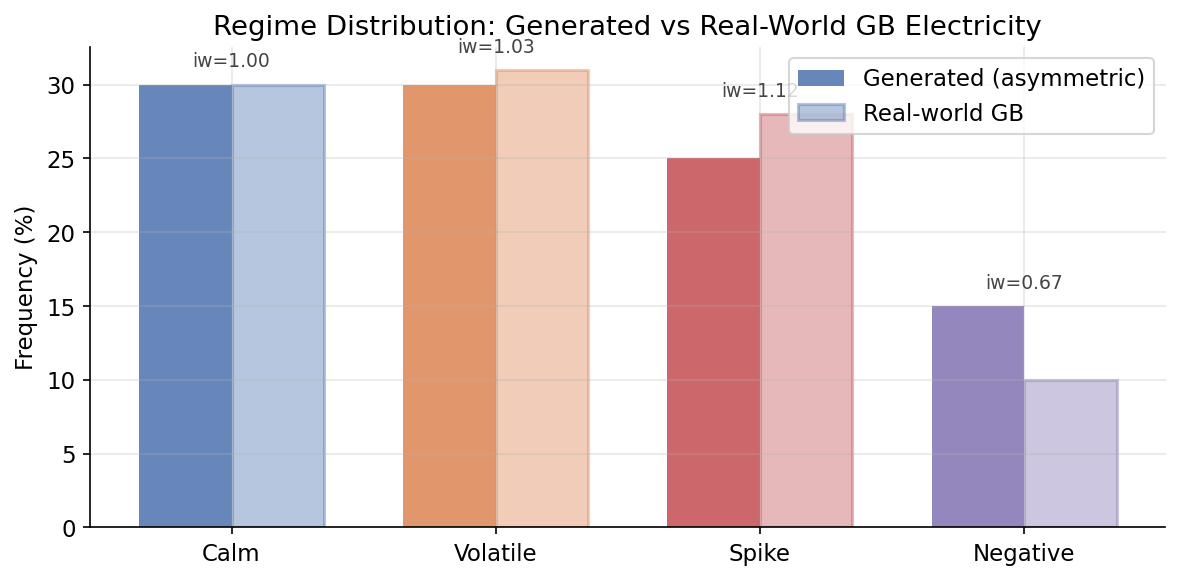

  regime  generated_count  generated_fraction  real_world_fraction  importance_weight
    calm             3000                0.30                 0.30             1.0000
volatile             3000                0.30                 0.31             1.0333
   spike             2500                0.25                 0.28             1.1200
negative             1500                0.15                 0.10             0.6667


In [16]:
df_rw = con.execute("""
    SELECT
        regime,
        generated_count,
        generated_fraction,
        real_world_fraction,
        importance_weight
    FROM regime_weights
    ORDER BY regime_id
""").df()

fig, ax = plt.subplots(figsize=(8, 4))

x      = np.arange(len(REGIME_ORDER))
width  = 0.35
labels = REGIME_ORDER

gen_fracs  = [df_rw.loc[df_rw.regime == r, "generated_fraction"].values[0]  for r in labels]
real_fracs = [df_rw.loc[df_rw.regime == r, "real_world_fraction"].values[0] for r in labels]

bars1 = ax.bar(x - width/2, [f*100 for f in gen_fracs],  width,
               label="Generated (asymmetric)",
               color=[REGIME_COLOURS[r] for r in labels], alpha=0.85)
bars2 = ax.bar(x + width/2, [f*100 for f in real_fracs], width,
               label="Real-world GB",
               color=[REGIME_COLOURS[r] for r in labels], alpha=0.40,
               edgecolor=[REGIME_COLOURS[r] for r in labels], linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels([r.capitalize() for r in labels])
ax.set_ylabel("Frequency (%)")
ax.set_title("Regime Distribution: Generated vs Real-World GB Electricity")
ax.legend()

# Annotate importance weights
for i, r in enumerate(labels):
    iw = df_rw.loc[df_rw.regime == r, "importance_weight"].values[0]
    ax.text(i, max(gen_fracs[i], real_fracs[i]) * 100 + 1.2,
            f"iw={iw:.2f}", ha="center", fontsize=9, color="#444")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_regime_distribution.png", dpi=150)
plt.show()
print(df_rw.to_string(index=False))

## Cell 5 — Section 2: Conditioning scalars by regime

Mean price, realised vol, total wind, net imbalance — broken down by regime.
These were the scalar conditioning inputs to the CVAE; the distributions
here reflect what the model was conditioned on for each regime.

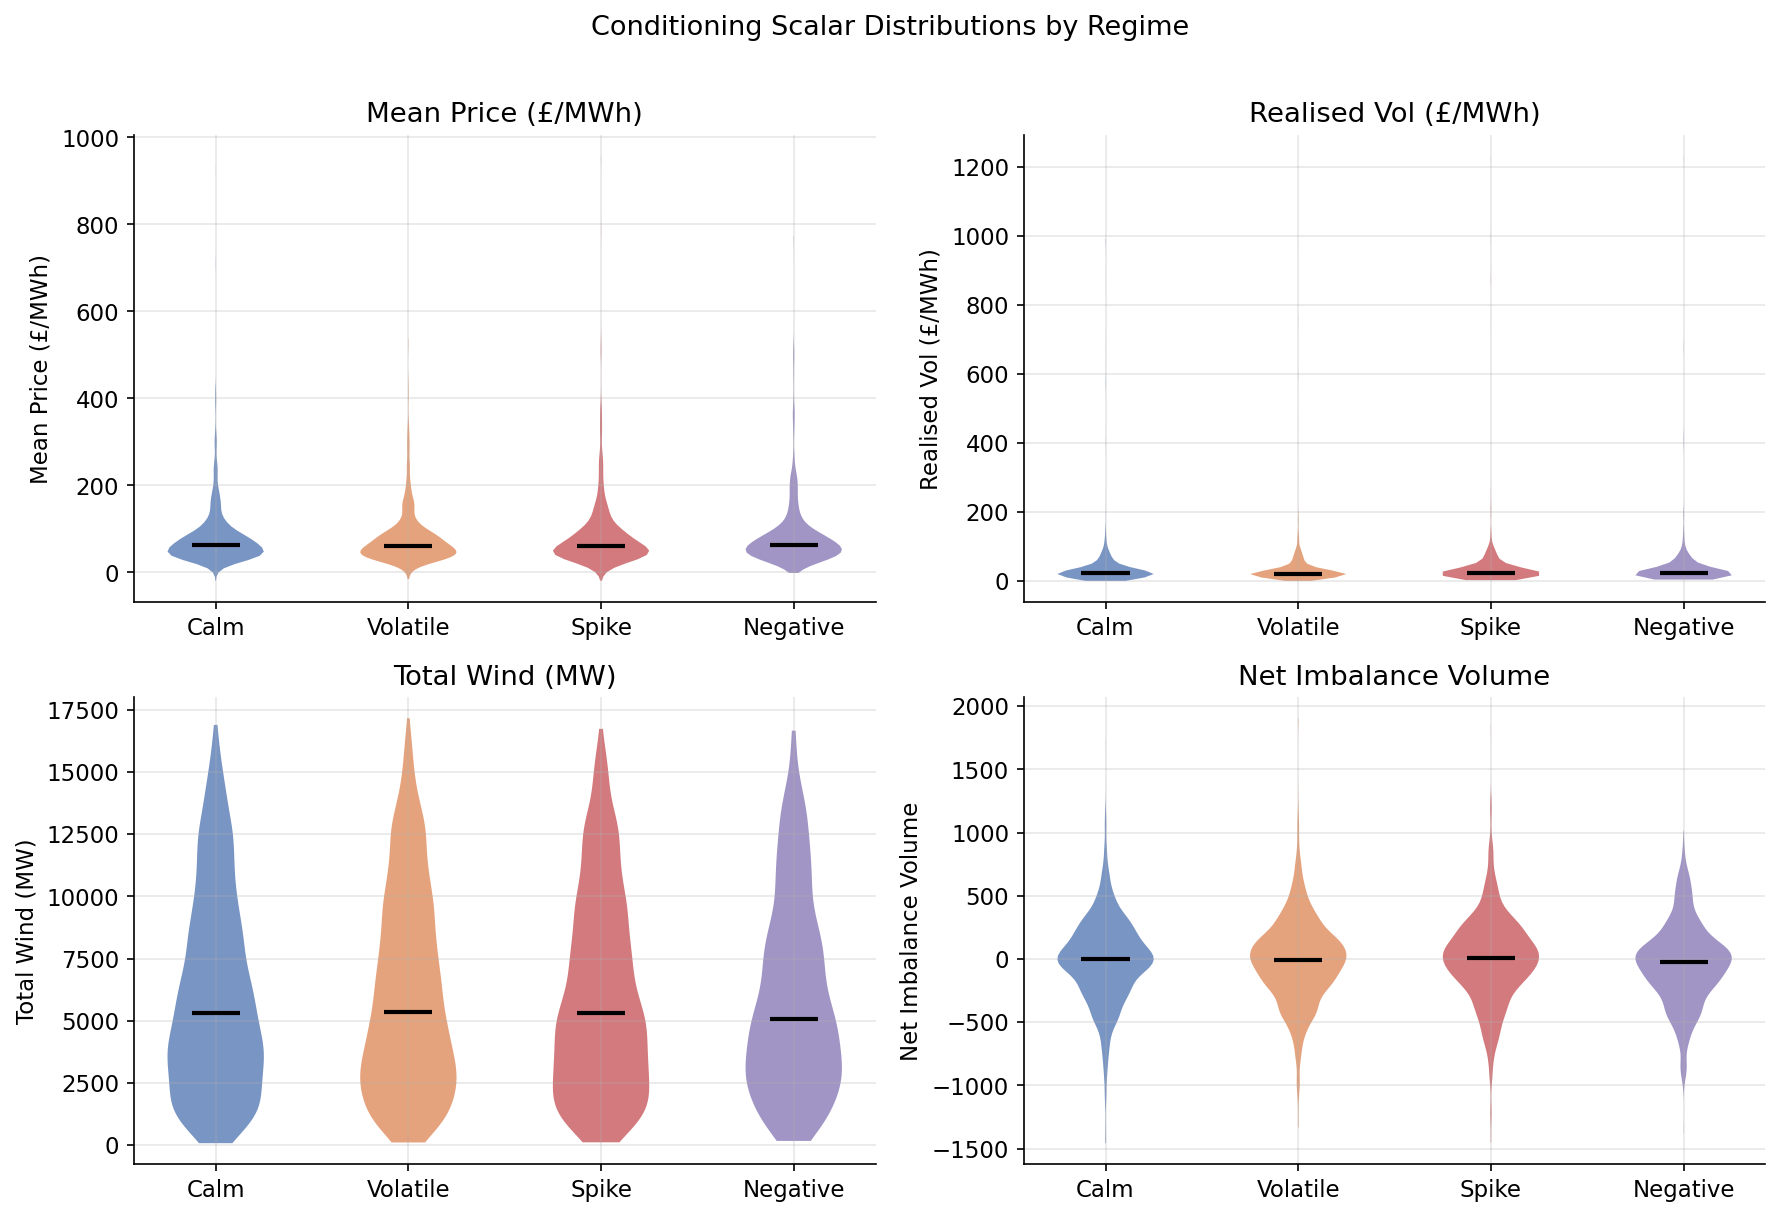


Summary statistics:
  regime  mean_price_avg  mean_price_std  vol_avg  vol_std  wind_avg  wind_std  imbal_avg  imbal_std
    calm           80.35           63.34    34.89    63.88   6076.68   3957.02     -10.06     333.65
negative           84.22           75.37    34.63    59.56   5954.91   3840.86     -38.85     319.92
   spike           85.80           77.61    35.28    60.46   6066.91   3942.03      -6.91     343.66
volatile           80.22           63.82    33.45    45.89   6132.26   3974.07     -14.81     335.50


In [17]:
df_scalars = con.execute("""
    SELECT
        regime,
        AVG(mean_price)              AS mean_price_avg,
        STDDEV(mean_price)           AS mean_price_std,
        AVG(realised_vol)            AS vol_avg,
        STDDEV(realised_vol)         AS vol_std,
        AVG(total_wind_mw)           AS wind_avg,
        STDDEV(total_wind_mw)        AS wind_std,
        AVG(net_imbalance_volume)    AS imbal_avg,
        STDDEV(net_imbalance_volume) AS imbal_std
    FROM scenarios
    GROUP BY regime
    ORDER BY regime
""").df()

# Load raw data for violin plots
df_raw = con.execute("""
    SELECT regime, mean_price, realised_vol, total_wind_mw, net_imbalance_volume
    FROM scenarios
""").df()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = [
    ("mean_price",           "Mean Price (£/MWh)",      axes[0, 0]),
    ("realised_vol",         "Realised Vol (£/MWh)",    axes[0, 1]),
    ("total_wind_mw",        "Total Wind (MW)",          axes[1, 0]),
    ("net_imbalance_volume", "Net Imbalance Volume",     axes[1, 1]),
]

for col, ylabel, ax in metrics:
    data_by_regime = [
        df_raw.loc[df_raw.regime == r, col].dropna().values
        for r in REGIME_ORDER
    ]
    parts = ax.violinplot(data_by_regime, positions=range(4),
                          showmedians=True, showextrema=False)
    for i, (pc, r) in enumerate(zip(parts["bodies"], REGIME_ORDER)):
        pc.set_facecolor(REGIME_COLOURS[r])
        pc.set_alpha(0.75)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(4))
    ax.set_xticklabels([r.capitalize() for r in REGIME_ORDER])
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

fig.suptitle("Conditioning Scalar Distributions by Regime", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_conditioning_scalars_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSummary statistics:")
print(df_scalars.round(2).to_string(index=False))

## Cell 6 — Section 3: Log-signature distributions by regime

Box plots for the first 8 active log-sig dimensions.
Well-separated boxes indicate the CVAE has learned regime-conditional
structure in path space, not just scalar differences.

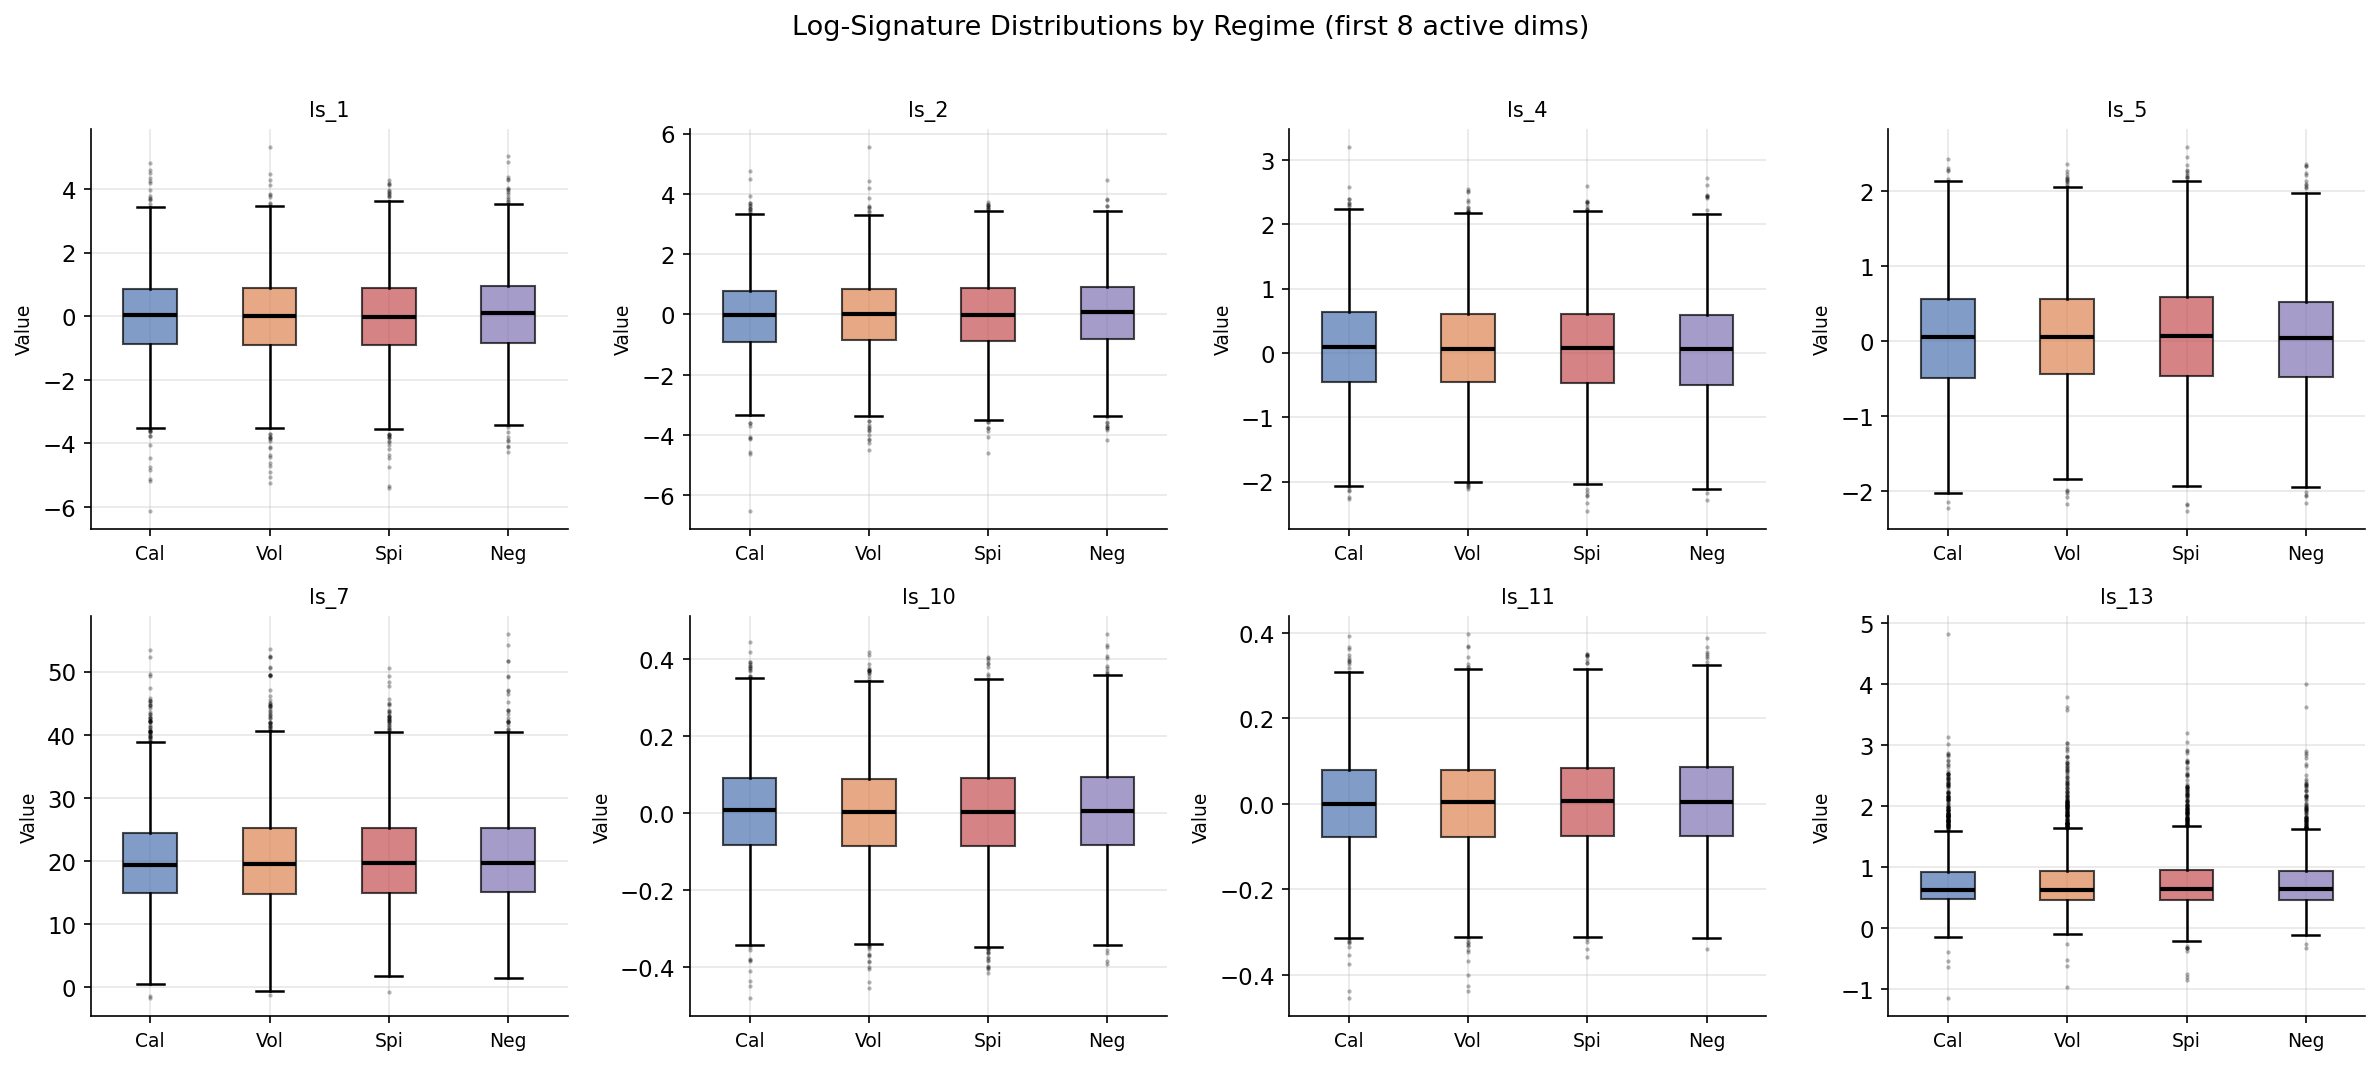

In [18]:
# Use first 8 ls_ columns for readability
plot_ls_cols = ls_cols[:8]

df_ls = con.execute(f"""
    SELECT regime, {', '.join(plot_ls_cols)}
    FROM scenarios
""").df()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, plot_ls_cols):
    data_by_regime = [
        df_ls.loc[df_ls.regime == r, col].values for r in REGIME_ORDER
    ]
    bp = ax.boxplot(
        data_by_regime,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    for patch, r in zip(bp["boxes"], REGIME_ORDER):
        patch.set_facecolor(REGIME_COLOURS[r])
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels([r[:3].capitalize() for r in REGIME_ORDER], fontsize=9)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Value", fontsize=9)

fig.suptitle(
    "Log-Signature Distributions by Regime (first 8 active dims)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_logsig_distributions_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 7 — Section 4: Importance-weighted reweighting

Compares raw (asymmetrically sampled) means against importance-weighted
means for each scalar. The weighted means should recover real-world averages.
This validates the reweighting logic before 07a/07d rely on it.

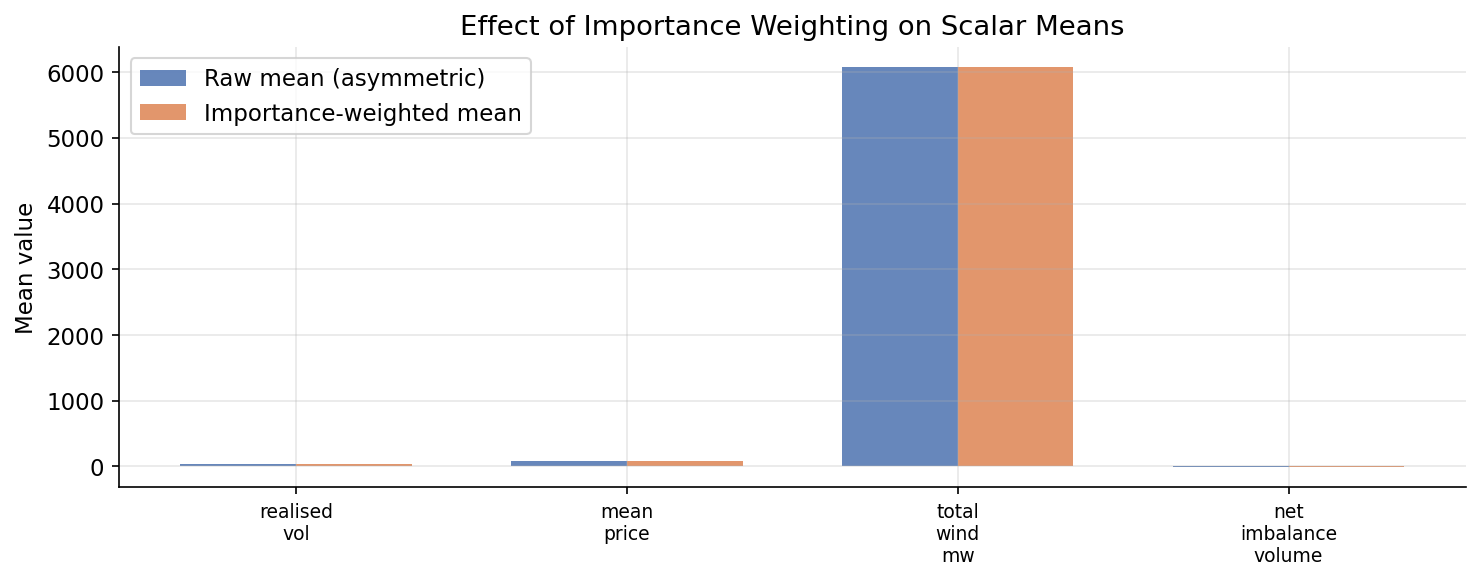

Raw means (asymmetric sampling):
  realised_vol                     34.515
  mean_price                       82.253
  total_wind_mw                  6072.647
  net_imbalance_volume            -15.015

Importance-weighted means:
  realised_vol                     34.521
  mean_price                       82.241
  total_wind_mw                  6079.021
  net_imbalance_volume            -13.564


In [19]:
# Raw means (no reweighting)
df_raw_means = con.execute(f"""
    SELECT
        AVG(mean_price)           AS mean_price,
        AVG(realised_vol)         AS realised_vol,
        AVG(total_wind_mw)        AS total_wind_mw,
        AVG(net_imbalance_volume) AS net_imbalance_volume
    FROM scenarios
""").df()

# Importance-weighted means
df_iw_means = con.execute(f"""
    SELECT
        SUM(mean_price           * importance_weight) / SUM(importance_weight) AS mean_price,
        SUM(realised_vol         * importance_weight) / SUM(importance_weight) AS realised_vol,
        SUM(total_wind_mw        * importance_weight) / SUM(importance_weight) AS total_wind_mw,
        SUM(net_imbalance_volume * importance_weight) / SUM(importance_weight) AS net_imbalance_volume
    FROM scenarios_weighted
""").df()

metrics = SCALAR_COND_NAMES
raw_vals = [df_raw_means[m].values[0] for m in metrics]
iw_vals  = [df_iw_means[m].values[0]  for m in metrics]

fig, ax = plt.subplots(figsize=(10, 4))
x     = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, raw_vals, width, label="Raw mean (asymmetric)", color="#4C72B0", alpha=0.85)
ax.bar(x + width/2, iw_vals,  width, label="Importance-weighted mean", color="#DD8452", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in metrics], fontsize=9)
ax.set_title("Effect of Importance Weighting on Scalar Means")
ax.set_ylabel("Mean value")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "04_importance_weighting_effect.png", dpi=150)
plt.show()

print("Raw means (asymmetric sampling):")
for m, v in zip(metrics, raw_vals):
    print(f"  {m:<28} {v:>10.3f}")
print("\nImportance-weighted means:")
for m, v in zip(metrics, iw_vals):
    print(f"  {m:<28} {v:>10.3f}")

## Cell 8 — Section 5: Log-signature correlation structure by regime

Heatmaps of the Pearson correlation matrix of log-sig dimensions,
one per regime. Structural differences across regimes reveal that
the CVAE has learned distinct path geometries per regime —
not just shifted means.

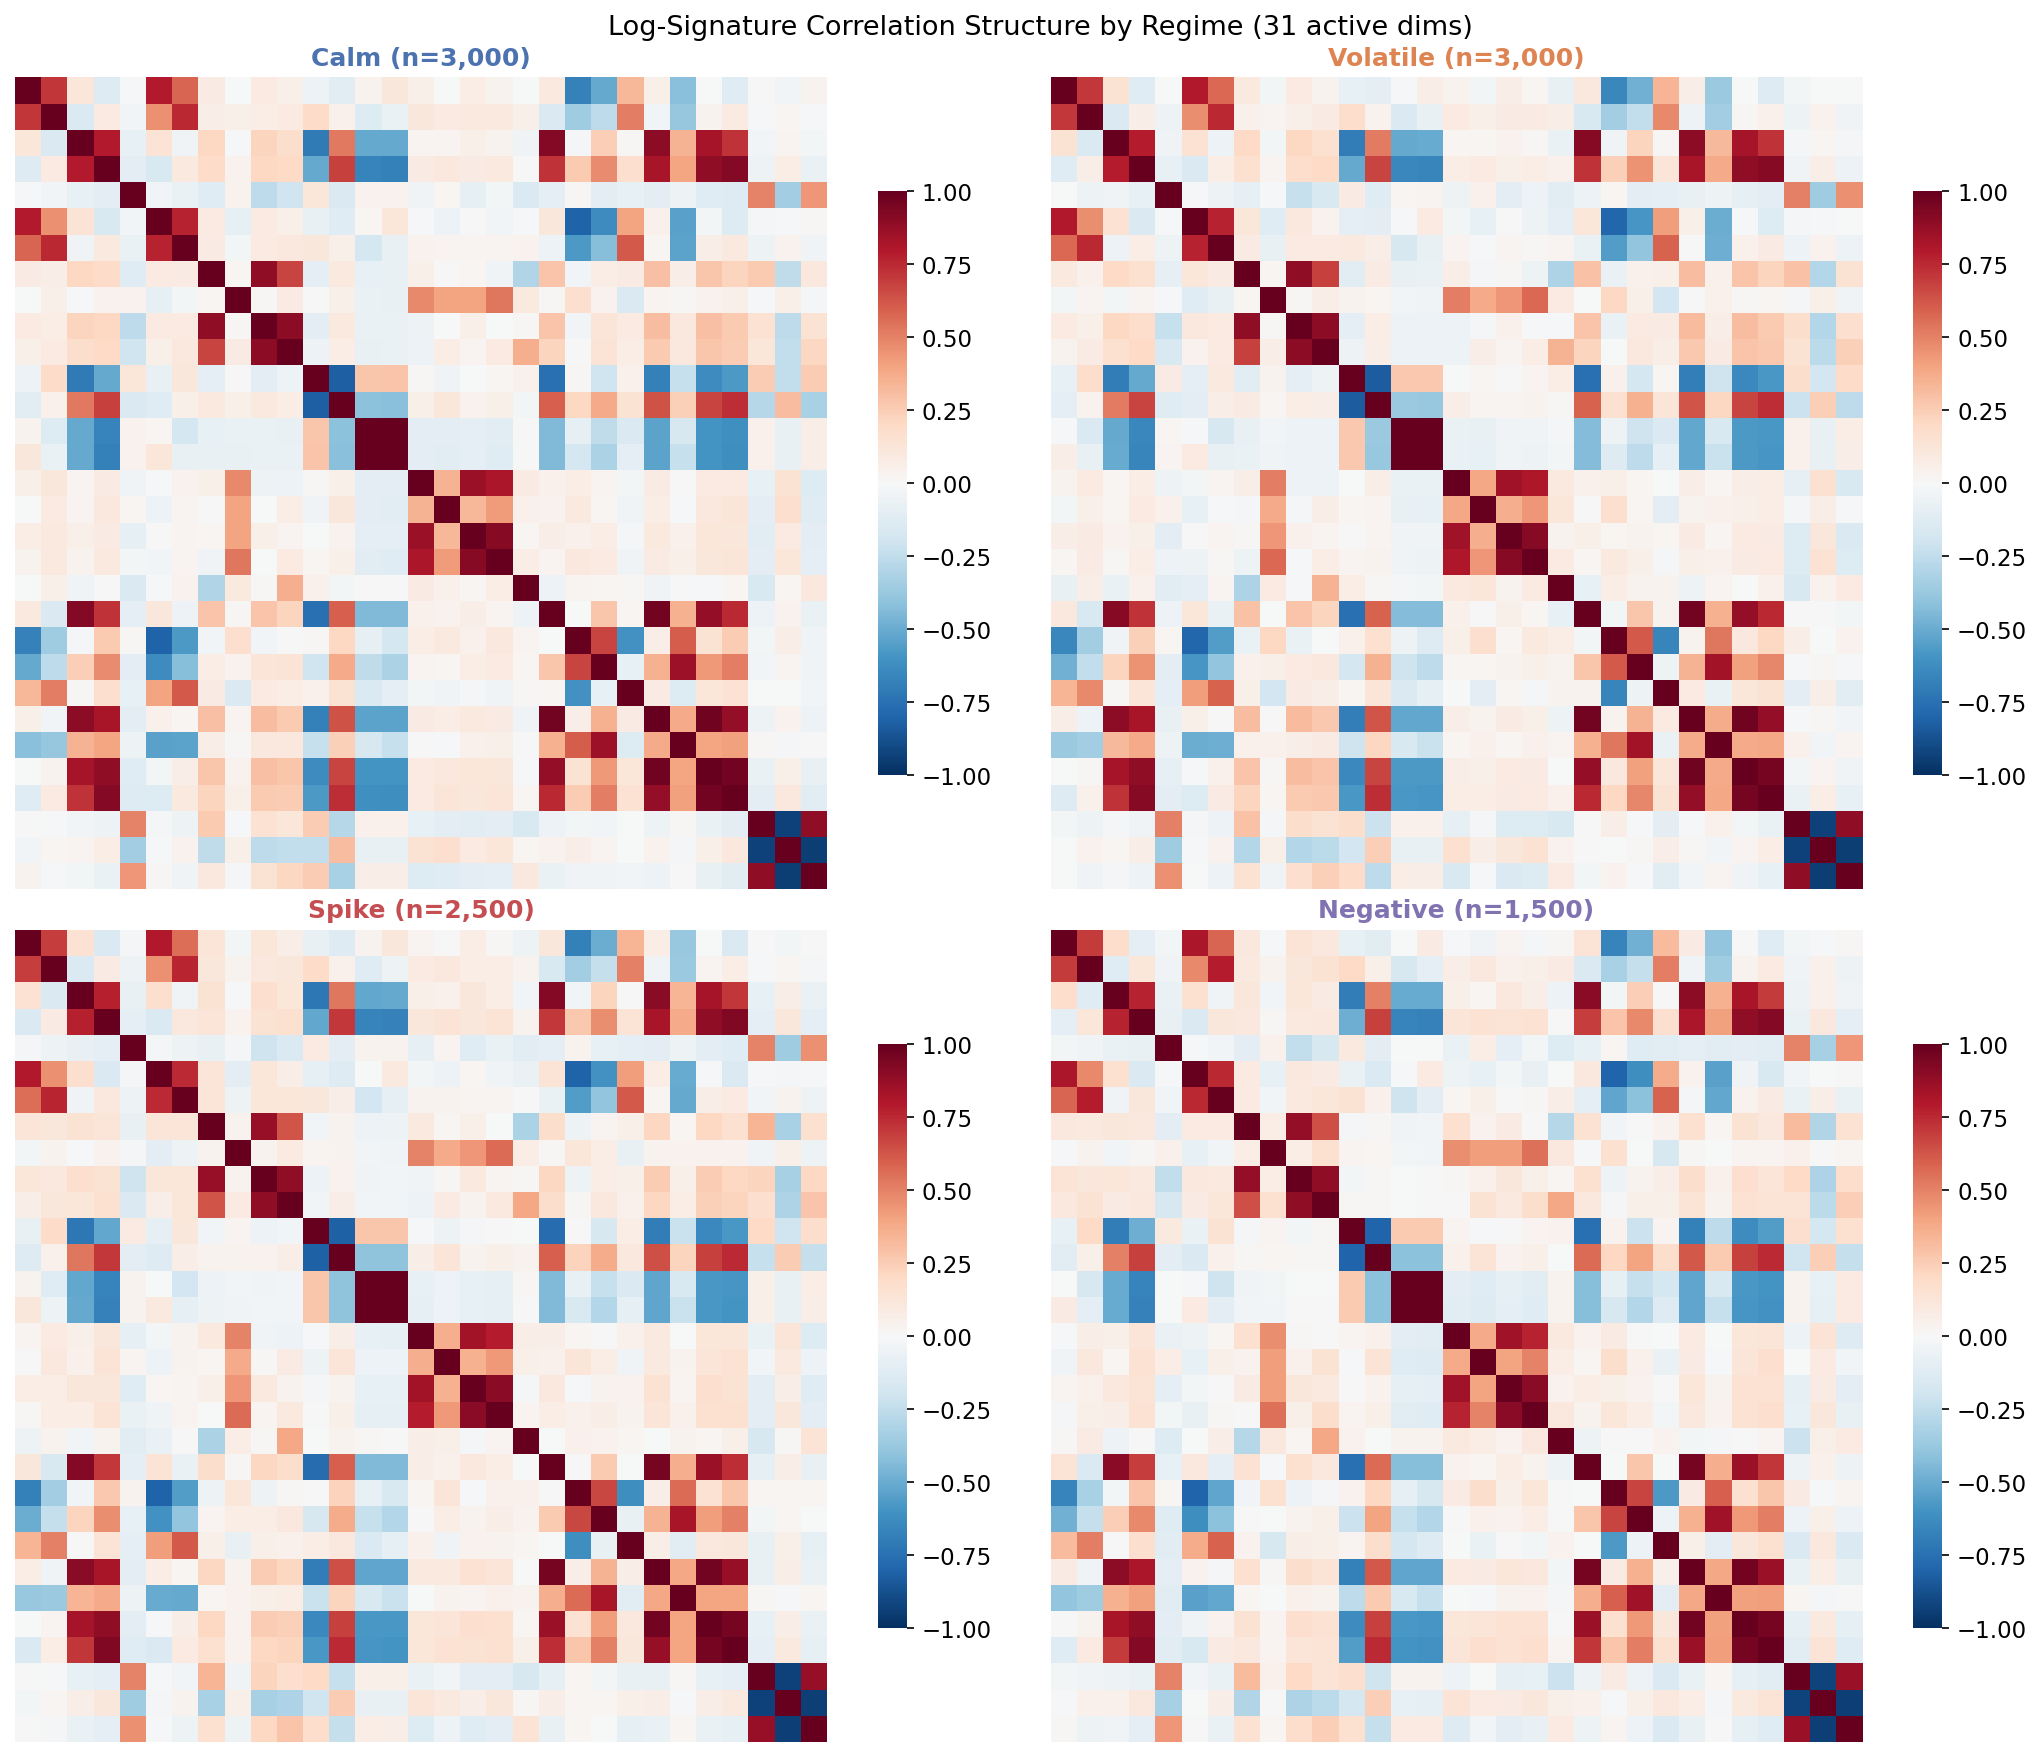

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, regime in zip(axes, REGIME_ORDER):
    df_r = con.execute(f"""
        SELECT {', '.join(ls_cols)}
        FROM scenarios
        WHERE regime = '{regime}'
    """).df()

    corr = df_r.corr()

    sns.heatmap(
        corr,
        ax=ax,
        cmap="RdBu_r",
        vmin=-1, vmax=1,
        center=0,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"shrink": 0.7},
        square=True,
    )
    n_regime = len(df_r)
    ax.set_title(
        f"{regime.capitalize()} (n={n_regime:,})",
        color=REGIME_COLOURS[regime],
        fontsize=12, fontweight="bold"
    )

fig.suptitle(
    "Log-Signature Correlation Structure by Regime (31 active dims)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_logsig_correlation_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 9 — Section 6: Scenario sampling patterns

Demonstrates the exact query patterns that 07a and 07d will use.
Validates that random sampling, regime filtering, and reweighted
sampling all work correctly from the live database.

In [21]:
# ── Pattern A: full log-sig matrix (for batch decoding in 07d) ────────────────
X_dict  = con.execute(f"SELECT {', '.join(ls_cols)} FROM scenarios ORDER BY scenario_id").fetchnumpy()
X_all   = np.stack([X_dict[c] for c in ls_cols], axis=1)
print(f"Pattern A — full log-sig matrix: {X_all.shape}")

# ── Pattern B: regime-filtered (for 07a gas storage control) ─────────────────
for regime in REGIME_ORDER:
    n = con.execute(f"SELECT COUNT(*) FROM scenarios WHERE regime = '{regime}'").fetchone()[0]
    df_sample = con.execute(f"""
        SELECT scenario_id, regime, {', '.join(ls_cols[:3])}
        FROM scenarios
        WHERE regime = '{regime}'
        USING SAMPLE 5 ROWS
    """).df()
    print(f"Pattern B — sample_regime('{regime}', n=5): {df_sample.shape}  (pool={n:,})")

# ── Pattern C: importance-weighted full sample (for 07d unbiased CVaR) ────────
df_wt = con.execute(f"""
    SELECT scenario_id, regime, importance_weight, {', '.join(ls_cols[:3])}
    FROM scenarios_weighted
    ORDER BY scenario_id
""").df()
print(f"\nPattern C — weighted sample: {df_wt.shape}")
print(f"  Importance weight range: [{df_wt.importance_weight.min():.3f}, {df_wt.importance_weight.max():.3f}]")

# ── Pattern D: retrieve model config (for loading CVAE decoder) ───────────────
print("\nPattern D — model config retrieval:")
for key in ["latent_dim", "hidden_dim", "n_layers", "cond_dim", "logsig_dim", "best_val_loss"]:
    val = con.execute(f"SELECT value FROM model_config WHERE key = '{key}'").fetchone()[0]
    print(f"  {key:<20} {val}")

Pattern A — full log-sig matrix: (10000, 31)
Pattern B — sample_regime('calm', n=5): (1, 5)  (pool=3,000)
Pattern B — sample_regime('volatile', n=5): (2, 5)  (pool=3,000)
Pattern B — sample_regime('spike', n=5): (1, 5)  (pool=2,500)
Pattern B — sample_regime('negative', n=5): (2, 5)  (pool=1,500)

Pattern C — weighted sample: (10000, 6)
  Importance weight range: [0.667, 1.120]

Pattern D — model config retrieval:
  latent_dim           24
  hidden_dim           384
  n_layers             2
  cond_dim             38
  logsig_dim           31
  best_val_loss        0.2701


## Cell 10 — Summary statistics table

A clean printable summary for the dissertation / README.

In [22]:
df_summary = con.execute("""
    SELECT
        s.regime,
        COUNT(*)                               AS n_scenarios,
        ROUND(100.0 * COUNT(*) / 10000, 1)    AS pct_generated,
        ROUND(rw.real_world_fraction * 100, 1) AS pct_real_world,
        ROUND(rw.importance_weight, 3)         AS importance_weight,
        ROUND(AVG(s.mean_price), 1)            AS avg_price_GBP,
        ROUND(AVG(s.realised_vol), 1)          AS avg_vol_GBP,
        ROUND(AVG(s.total_wind_mw), 0)         AS avg_wind_MW
    FROM scenarios s
    JOIN regime_weights rw ON s.regime = rw.regime
    GROUP BY s.regime, rw.regime_id, rw.real_world_fraction, rw.importance_weight
    ORDER BY rw.regime_id
""").df()

print("=" * 75)
print("SCENARIO DATABASE SUMMARY")
print("=" * 75)
print(df_summary.to_string(index=False))
print("=" * 75)

# Validation summary
print("\nModel validation (notebook 05):")
df_val = con.execute("""
    SELECT metric, result FROM validation_summary
    WHERE metric NOT IN ('notes')
""").df()
for _, row in df_val.iterrows():
    print(f"  {row['metric']:<25} {row['result']}")

SCENARIO DATABASE SUMMARY
  regime  n_scenarios  pct_generated  pct_real_world  importance_weight  avg_price_GBP  avg_vol_GBP  avg_wind_MW
    calm         3000           30.0            30.0              1.000           80.3         34.9       6077.0
volatile         3000           30.0            31.0              1.033           80.2         33.5       6132.0
   spike         2500           25.0            28.0              1.120           85.8         35.3       6067.0
negative         1500           15.0            10.0              0.667           84.2         34.6       5955.0

Model validation (notebook 05):
  sig_mmd_pass              True
  sig_mmd_pvalue            0.84
  sig_mmd_stat              -0.0006314498068424675
  ks_pass_rate              0.5806451612903226
  ks_median_stat            0.08
  std_net_move_match        True
  skew_net_move_match       False
  kurtosis_match            False
  levy_area_match           True
  large_move_rate_match     True
  n_real    

## Cell 11 — Close connection and report saved figures

In [23]:
con.close()

print("Figures saved to:", FIG_DIR)
for fp in sorted(FIG_DIR.glob("*.png")):
    print(f"  {fp.name}  ({fp.stat().st_size / 1024:.1f} KB)")

print("\nNotebook 07b complete.")
print("Next: 07a (gas storage stochastic control)")

Figures saved to: /content/drive/MyDrive/energy_synthetic_data/data/figures
  01_regime_distribution.png  (52.2 KB)
  02_conditioning_scalars_by_regime.png  (174.4 KB)
  03_logsig_distributions_by_regime.png  (107.5 KB)
  04_importance_weighting_effect.png  (50.9 KB)
  05_logsig_correlation_by_regime.png  (102.5 KB)

Notebook 07b complete.
Next: 07a (gas storage stochastic control)
